In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('ecommerce_orders_dataset.csv')
df.head()

,Order_ID,Customer_ID,Order_Date,Year,Month,Day,Day_Of_Week,Quarter,Customer_Age,Customer_Gender,...,Delivery_Days,Order_Status,Returned,Review_Rating,Customer_Lifetime_Value,Profit_Margin_Percent,Profit_Amount,Season,Holiday_Season,High_Value_Order
0,615717,CUST007322,2023-01-01,2023,1,1,Sunday,1,32,Male,...,2,Delivered,No,4.4,2144.92,23.10,15.75,Winter,No,No
1,626919,CUST004717,2023-01-01,2023,1,1,Sunday,1,50,Male,...,9,Delivered,No,4.1,817.17,8.57,3.32,Winter,No,No
2,615781,CUST004415,2023-01-01,2023,1,1,Sunday,1,61,Male,...,2,Delivered,No,5.0,541.16,29.72,45.67,Winter,No,No
3,621747,CUST004114,2023-01-01,2023,1,1,Sunday,1,34,Male,...,6,Returned,Yes,3.4,700.49,25.22,75.25,Winter,No,No
4,625881,CUST000145,2023-01-01,2023,1,1,Sunday,1,37,Male,...,8,Delivered,No,3.6,2133.77,24.64,26.06,Winter,No,No


In [4]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

*   What is the total Order_Amount and the total Profit_Amount generated by each Product_Category?

In [5]:
per_category_data = df.groupby('Product_Category')[['Order_Amount','Profit_Amount']].sum().reset_index()
per_category_data = per_category_data.sort_values(by='Profit_Amount',ascending=False)
per_category_data

,Product_Category,Order_Amount,Profit_Amount
2,Electronics,6320059.31,1040688.00
5,Home & Kitchen,1768963.43,379418.20
3,Fashion,1323929.17,344642.74
6,Sports,661447.69,139758.27
0,Beauty,460243.32,134401.18
4,Groceries,360727.15,76057.26
7,Toys,279307.23,60150.95
1,Books,195366.69,40799.67


In [6]:
fig = px.bar(
    per_category_data,
    x='Profit_Amount',
    y='Product_Category',
    orientation='h',
    title='Total Profit Amount by Product Category',
    labels={
        'Profit_Amount' : 'Total Profit ($)',
        'Product_Category' : 'Product Category'
    },
    color='Profit_Amount',
    color_continuous_scale='viridis'
)

fig.update_yaxes(categoryorder='total ascending')
fig.show()

*   Does the average Review_Rating vary significantly across different Membership_Status levels (e.g., Silver, Gold, Standard)? Find the mean rating and total number of orders for each membership tier.

In [7]:
membership_analysis = df.groupby('Membership_Status').agg(
    Average_Review_Rating=('Review_Rating','mean'),
    Total_Orders=('Order_ID','count')
).reset_index()
membership_analysis


,Membership_Status,Average_Review_Rating,Total_Orders
0,Gold,4.031326,4916
1,Platinum,4.203242,1789
2,Silver,4.035592,7246
3,Standard,4.041386,16049


In [8]:
fig = px.box(
    df,
    x='Membership_Status',
    y='Review_Rating',
    color='Membership_Status',
    title='Interactive Review Rating Distribution by Membership Tier',
    labels={'Membership_Status': 'Membership Status', 'Review_Rating': 'Review Rating'},
)
fig.show()

*   Which Month of the year generates the highest total revenue (Order_Amount)?

In [9]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

In [10]:
monthly_revenue = df.groupby('Month')['Order_Amount'].sum().sort_values(ascending=False).reset_index()
monthly_revenue

,Month,Order_Amount
0,8,1071268.49
1,3,1010299.50
2,12,993858.06
3,1,936076.62
4,11,930805.06
5,7,930656.68
6,4,924831.93
7,2,921195.64
8,9,919010.17
9,6,918539.05


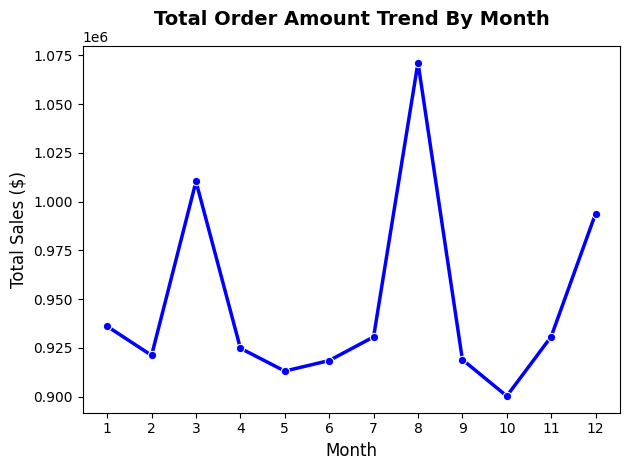

In [11]:
sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='Order_Amount',
    marker='o',
    color='b',
    linewidth=2.5
)
plt.title('Total Order Amount Trend By Month',fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Total Sales ($)',fontsize=12)
plt.tight_layout()
plt.xticks(range(1,13))
plt.show()

*   What percentage of orders are flagged as a High_Value_Order? Does this percentage change significantly depending on the Traffic_Source (e.g., Direct, Paid Ads, Social Media) that brought the customer to the platform?

In [12]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

In [13]:
grouped_data = df.groupby(['Traffic_Source','High_Value_Order']).agg(
    Order_Count = ('Order_ID','count')
).reset_index()
grouped_data['Percentage'] = (
    grouped_data['Order_Count'] /
    grouped_data.groupby('Traffic_Source')['Order_Count'].transform('sum')
) * 100
grouped_data

,Traffic_Source,High_Value_Order,Order_Count,Percentage
0,Direct,No,3776,74.433274
1,Direct,Yes,1297,25.566726
2,Email,No,3709,74.944433
3,Email,Yes,1240,25.055567
4,Organic Search,No,3838,75.284425
5,Organic Search,Yes,1260,24.715575
6,Paid Ads,No,3597,74.766161
7,Paid Ads,Yes,1214,25.233839
8,Referral,No,3789,75.628743
9,Referral,Yes,1221,24.371257


In [14]:
fig = px.bar(
    grouped_data,
    x='Traffic_Source',
    y='Percentage',
    color='High_Value_Order',
    barmode='group',
    title = 'Percentage of high value orders by traffic source',
    labels={'Percentage': 'Percentage (%)', 'Traffic_Source': 'Traffic Source'},
)
fig.update_layout(title_x=0.5)
fig.show()

*   Which shipping method is the most efficient, and which experiences the longest delays?

In [17]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Year', 'Month', 'Day',
       'Day_Of_Week', 'Quarter', 'Customer_Age', 'Customer_Gender', 'Country',
       'City', 'Customer_Segment', 'Product_ID', 'Product_Category',
       'Product_Subcategory', 'Brand', 'Unit_Price', 'Quantity',
       'Discount_Percent', 'Discount_Amount', 'Coupon_Used', 'Shipping_Cost',
       'Tax_Amount', 'Order_Amount', 'Payment_Method', 'Device_Type',
       'Traffic_Source', 'Membership_Status', 'Shipping_Method',
       'Warehouse_Region', 'Delivery_Days', 'Order_Status', 'Returned',
       'Review_Rating', 'Customer_Lifetime_Value', 'Profit_Margin_Percent',
       'Profit_Amount', 'Season', 'Holiday_Season', 'High_Value_Order'],
      dtype='str')

In [25]:
shipping_efficiency = df.groupby('Shipping_Method')['Delivery_Days'].mean().round(2).reset_index().sort_values(by='Delivery_Days')
shipping_efficiency

,Shipping_Method,Delivery_Days
2,Same Day,1.67
0,Express,3.31
3,Standard,5.28
1,Pickup,5.29


In [ ]:
fig = px.bar(
    shipping_efficiency,
    x='Shipping_Method',
    y='Delivery_Days',
    color='Delivery_Days',
    title='Average days for delivery by methods',
    labels={
        "Shipping_Method" : 'Method',
        "Delivery_Days" : "Avg Days"
    }
)
fig.show()
